In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,roc_auc_score,roc_curve

In [5]:
np.random.seed(42)

n=300

data=pd.DataFrame({
    "age":np.random.randint(18,60,n),
    "salary":np.random.randint(20000,100000,n),
    "balance": np.random.randint(0,200000,n),
})

data["churn"] = (
    (data["balance"]>100000) &
    (data["salary"]>40000)
).astype(int)

data.head()

,age,salary,balance,churn
0,56,59790,52528,0
1,46,25600,38413,0
2,32,60764,52638,0
3,25,94543,183808,1
4,38,65714,110133,1


In [6]:
print(data.shape)
print(data.info())
print(data.describe)

print(data['churn'].value_counts())



(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
<bound method NDFrame.describe of      age  salary  balance  churn
0     56   59790    52528      0
1     46   25600    38413      0
2     32   60764    52638      0
3     25   94543   183808      1
4     38   65714   110133      1
..   ...     ...      ...    ...
295   51   41732   116148      1
296   38   50354   158357      1
297   47   33843   116421      0
298   50   91726     1605      0
299   45   37640    72303      0

[300 rows x 4 columns]>
churn
0    180
1    120
Name: count, dtype: int64


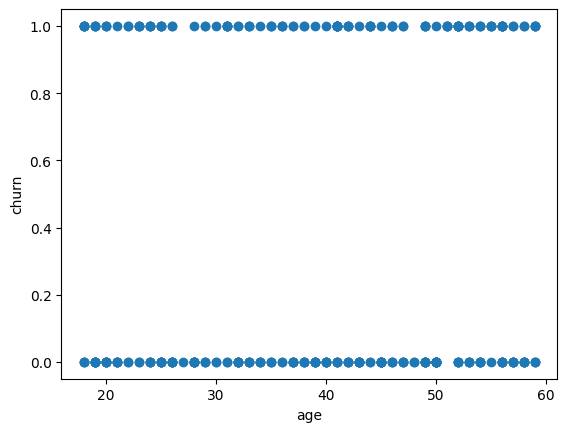

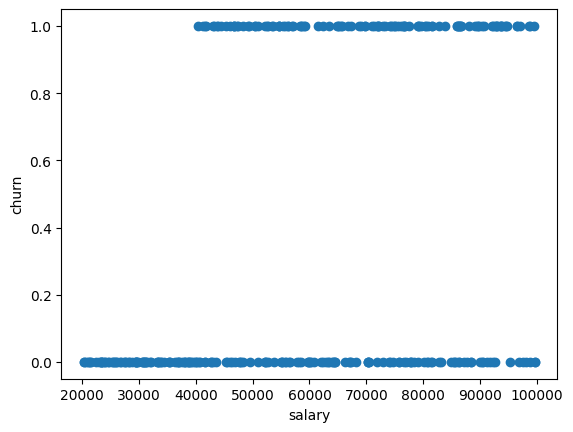

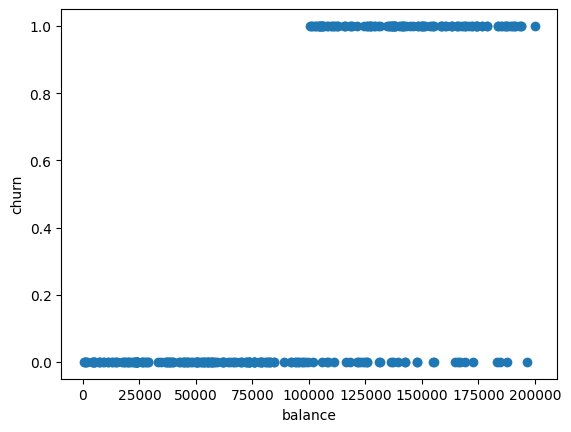

In [7]:
features=["age","salary","balance"]

for col in features:
    plt.figure()
    plt.scatter(data[col], data["churn"])
    plt.xlabel(col)
    plt.ylabel("churn")
    plt.show()

In [8]:
x=data[["age","salary","balance"]]
y=data["churn"]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [10]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)[:,1]

In [21]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("Classification Report:\n", classification_report(y_test,y_pred))
print("ROC AUC Score:", roc_auc_score(y_test,y_prob))

Accuracy: 0.8666666666666667
Confusion Matrix:
 [[32  1]
 [ 7 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89        33
           1       0.95      0.74      0.83        27

    accuracy                           0.87        60
   macro avg       0.89      0.86      0.86        60
weighted avg       0.88      0.87      0.86        60

ROC AUC Score: 0.9719416386083053


In [22]:
coeff_df=pd.DataFrame({
    "Features": x.columns,
    "Coefficient": model.coef_[0]
})

print(coeff_df)

  Features  Coefficient
0      age     0.025152
1   salary     0.000078
2  balance     0.000061


In [25]:
new_data=pd.DataFrame({
    "age":[35],
    "salary":[30000],
    "balance":[150000]
})

print("Churn Prediction:", model.predict(new_data)[0])
print("probability:", model.predict_proba(new_data)[0][1])

Churn Prediction: 0
probability: 0.3666050865391888
